In [9]:
# Import the libraries we need
import pandas as pd             # For working with the data table
import seaborn as sns           # For making nice charts
import matplotlib.pyplot as plt # For displaying the charts
import plotly.express as px     # For the interactive map

# I like this professional looking style
sns.set_theme(style="darkgrid", palette="PuBu")

# Load the dataset
df = pd.read_csv('global_housing_market_extended.csv')

# First 5 rows 
print("Data loaded successfully!")
display(df.head())

Data loaded successfully!


,Country,Year,House Price Index,Rent Index,Affordability Ratio,Mortgage Rate (%),Inflation Rate (%),GDP Growth (%),Population Growth (%),Urbanization Rate (%),Construction Index
0,USA,2015,117.454012,116.550001,9.587945,4.493292,1.514121,-0.752044,-0.796707,85.985284,118.089201
1,USA,2016,150.807258,51.440915,11.729189,5.662213,1.880204,-0.545400,-0.358084,69.127267,111.980515
2,USA,2017,123.194502,70.386040,8.506676,2.197469,2.398940,0.930895,0.596245,83.555279,85.973903
3,USA,2018,131.423444,91.469020,3.418054,4.537724,1.608407,-1.479587,2.321099,88.968961,134.671788
4,USA,2019,110.461377,56.837048,9.158097,3.700762,1.293249,1.961415,-0.879640,87.279612,90.702399


In [18]:
# DATA CLEANING

# 1. Rename columns to be shorter and easier to use
df = df.rename(columns={
    'House Price Index': 'Price_Index',
    'Rent Index': 'Rent_Index',
    'Mortgage Rate (%)': 'Mortgage_Rate',
    'Affordability Ratio': 'Affordability',
    'GDP Growth (%)': 'GDP_Growth',
    'Inflation Rate (%)': 'Inflation',
    'Urbanization Rate (%)': 'Urbanization'
})

# 2. Drop duplicates
df = df.drop_duplicates()

# 3. Drop missing values
df = df.dropna()

# Check the clean data
print("Cleaning complete!")
df.info()

Cleaning complete!
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                200 non-null    object 
 1   Year                   200 non-null    int64  
 2   Price_Index            200 non-null    float64
 3   Rent_Index             200 non-null    float64
 4   Affordability          200 non-null    float64
 5   Mortgage_Rate          200 non-null    float64
 6   Inflation              200 non-null    float64
 7   GDP_Growth             200 non-null    float64
 8   Population Growth (%)  200 non-null    float64
 9   Urbanization           200 non-null    float64
 10  Construction Index     200 non-null    float64
dtypes: float64(9), int64(1), object(1)
memory usage: 17.3+ KB


Summary Statistics:


,Year,Price_Index,Rent_Index,Affordability,Mortgage_Rate,Inflation,GDP_Growth,Population Growth (%),Urbanization,Construction Index,GDP_Size
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,2019.500000,130.381022,83.048370,7.237768,4.150621,3.649756,2.133722,0.722806,74.769891,111.204257,3.666321
std,2.879489,28.752229,21.439858,2.576085,1.380222,1.881938,2.413270,1.035691,8.734246,24.309473,1.804031
min,2015.000000,80.552212,50.354311,3.041688,1.537814,0.532110,-1.921833,-0.961391,60.172760,70.968678,1.018152
25%,2017.000000,104.142562,60.466671,5.034207,3.045278,1.939199,-0.095628,-0.183320,66.923842,90.182198,2.115892
50%,2019.500000,129.193653,83.721711,7.375697,4.329643,3.664625,2.307548,0.722372,75.100060,110.593807,3.307548
75%,2022.000000,157.127098,100.604665,9.276196,5.217706,5.261720,4.272776,1.621317,82.677430,133.780445,5.272776
max,2024.000000,179.971767,119.855388,11.879671,6.485623,6.912349,5.958931,2.497948,89.788944,149.735748,6.958931


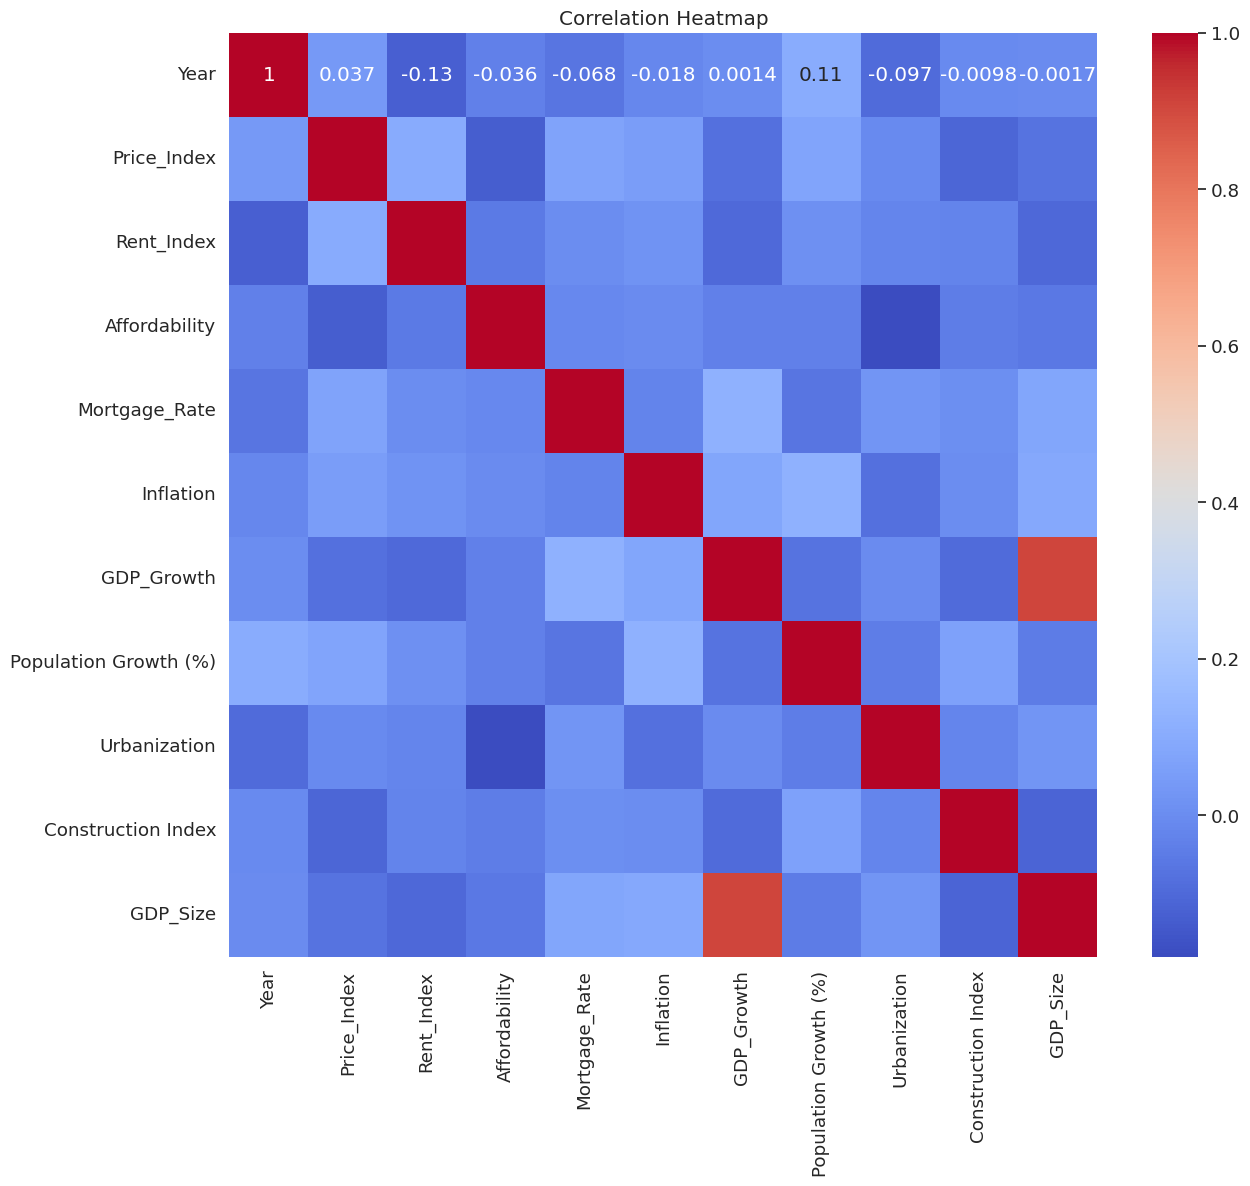

In [51]:
# EXPLORATORY ANALYSIS
# 1. Summary Statistics (Mean, Min, Max for each column)
print("Summary Statistics:")
display(df.describe())

# 2. Correlation Heatmap
plt.figure(figsize=(14,12))
numeric_df = df.select_dtypes(include='number')
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm',)
plt.title('Correlation Heatmap')
plt.show()


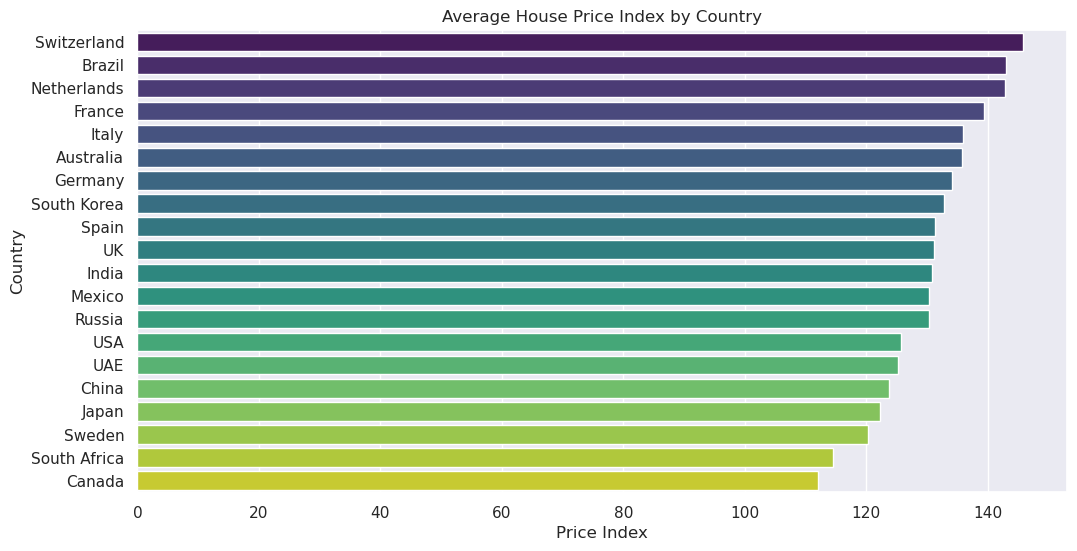

In [21]:
# REQUIRED VISUALIZATIONS

# 1. Bar Plot: Average House Price Index by Country
# We calculate the average price for each country first
avg_price = df.groupby('Country')['Price_Index'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_price.values, y=avg_price.index, palette='viridis')
plt.title('Average House Price Index by Country')
plt.xlabel('Price Index')
plt.show()

# 2. Histogram: Mortgage Rate Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Mortgage_Rate'], bins=20, kde=True, color='blue')
plt.title('Distribution of Mortgage Rates')
plt.xlabel('Mortgage Rate (%)')
plt.show()

# 3. Scatter Plot: House Price vs. Rent Index
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rent_Index', y='Price_Index', hue='Country', palette='deep')
plt.title('House Price Index vs. Rent Index')
plt.xlabel('Rent Index')
plt.ylabel('House Price Index')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend to the side
plt.show()

# 4. Line Plot: Affordability Ratio Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Affordability', hue='Country', marker='o')
plt.title('Affordability Ratio Trends (2015-2024)')
plt.ylabel('Affordability Ratio (Higher = Less Affordable)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# 5. Geo Map: Global House Prices
# This creates an interactive map
fig = px.choropleth(df, 
                    locations="Country", 
                    locationmode='country names',
                    color="Price_Index", 
                    hover_name="Country", 
                    animation_frame="Year",
                    color_continuous_scale="Plasma",
                    title="Global House Price Index Map")
fig.show()

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



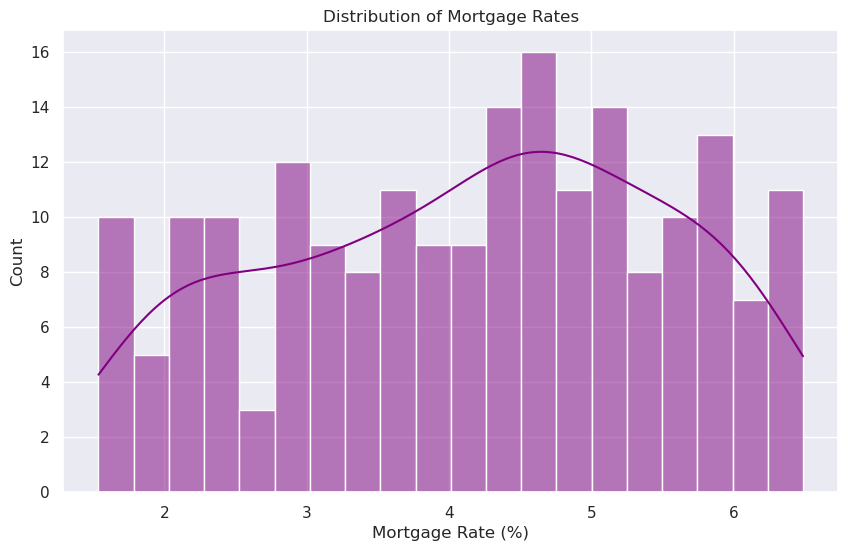

In [23]:
# 2. Histogram: Mortgage Rate Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Mortgage_Rate'], bins=20, kde=True, color='purple')
plt.title('Distribution of Mortgage Rates')
plt.xlabel('Mortgage Rate (%)')
plt.show()


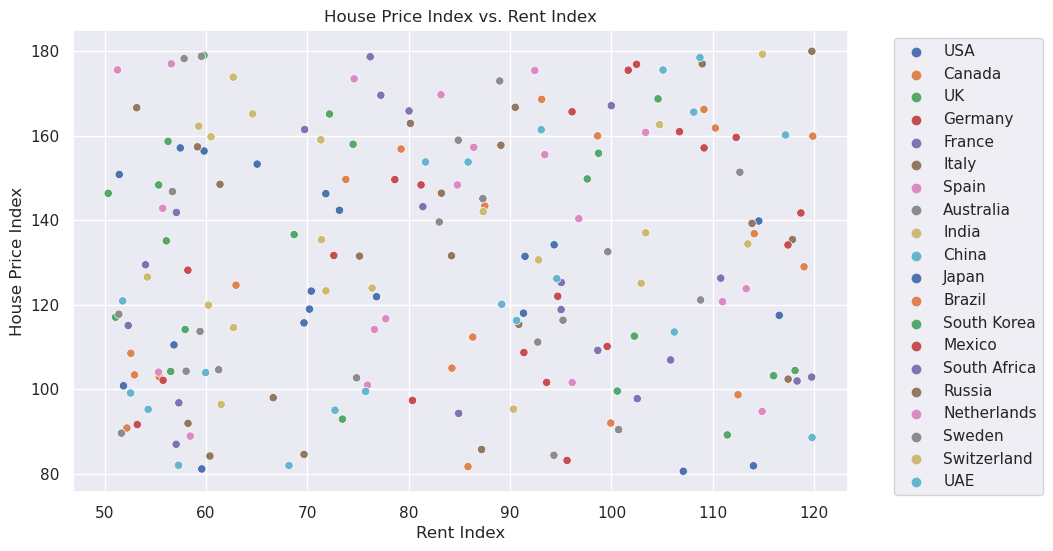

In [24]:
# 3. Scatter Plot: House Price vs. Rent Index
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Rent_Index', y='Price_Index', hue='Country', palette='deep')
plt.title('House Price Index vs. Rent Index')
plt.xlabel('Rent Index')
plt.ylabel('House Price Index')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend to the side
plt.show()



/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/conda/envs/anaconda-2024.02-py310/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



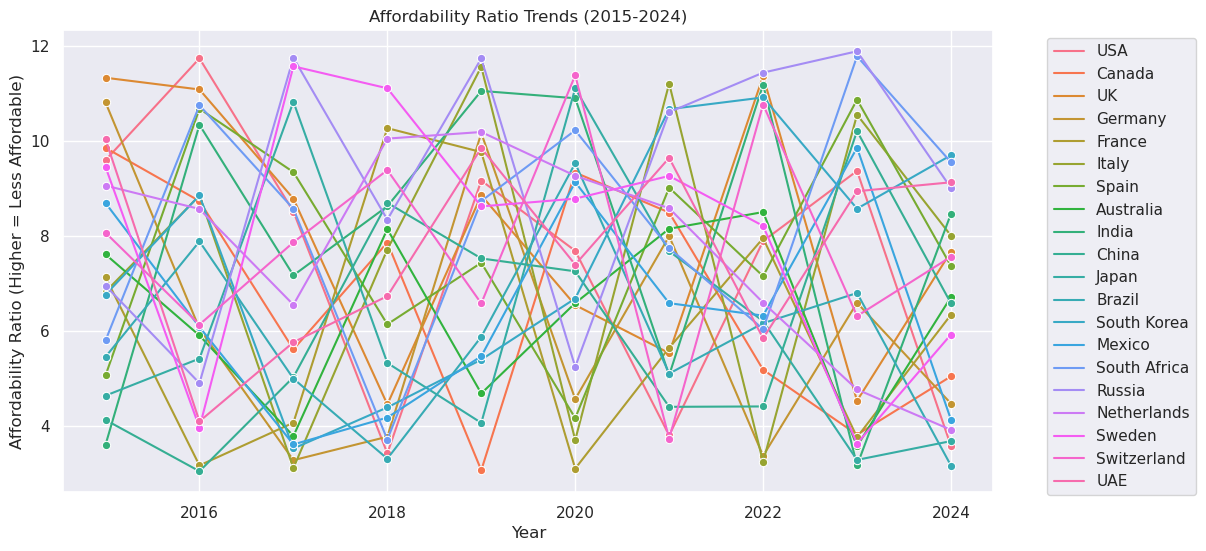

In [25]:
# 4. Line Plot: Affordability Ratio Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Affordability', hue='Country', marker='o')
plt.title('Affordability Ratio Trends (2015-2024)')
plt.ylabel('Affordability Ratio (Higher = Less Affordable)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()



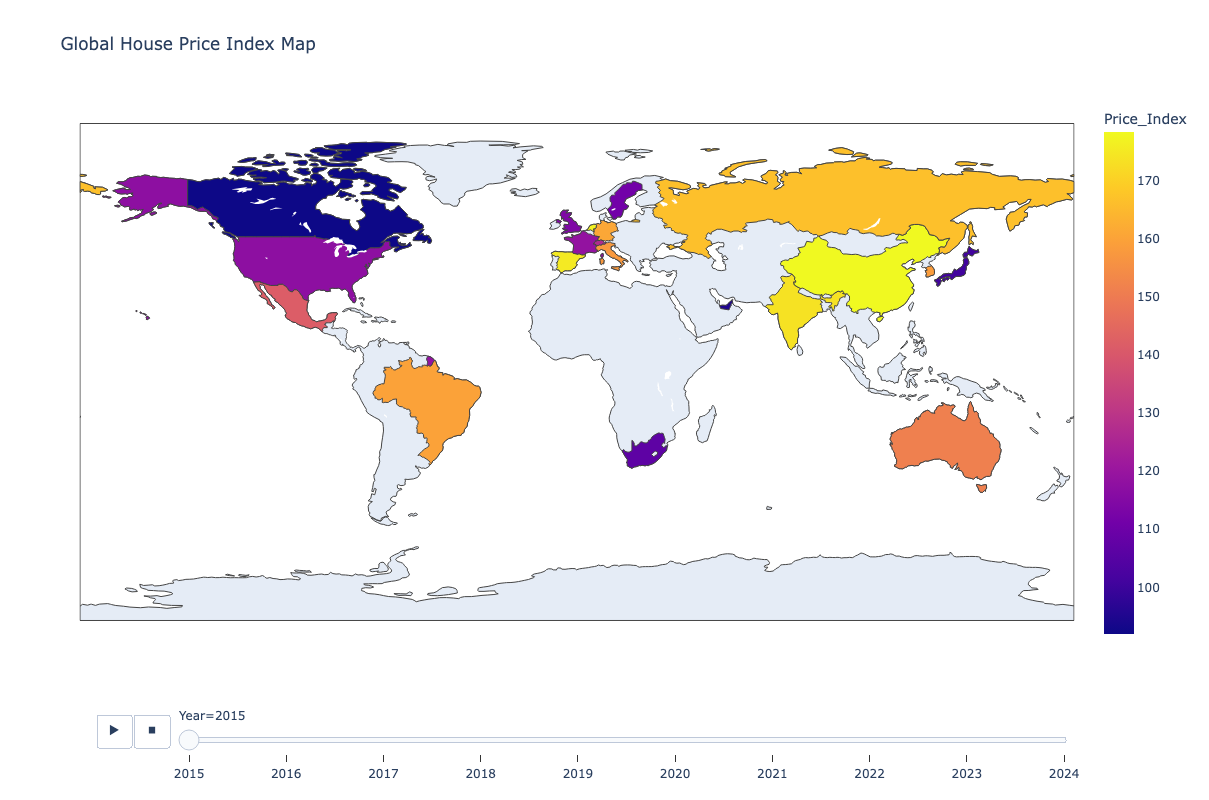

In [30]:
# 5. Geo Map: Global House Prices
# This creates an interactive map
fig = px.choropleth(df, 
                    locations="Country", 
                    locationmode='country names',
                    color="Price_Index", 
                    hover_name="Country", 
                    animation_frame="Year",
                    color_continuous_scale="Plasma",
                    title="Global House Price Index Map")
# Wanted the graph to be bigger
fig.update_layout(height=800, width=1200)
fig.show()

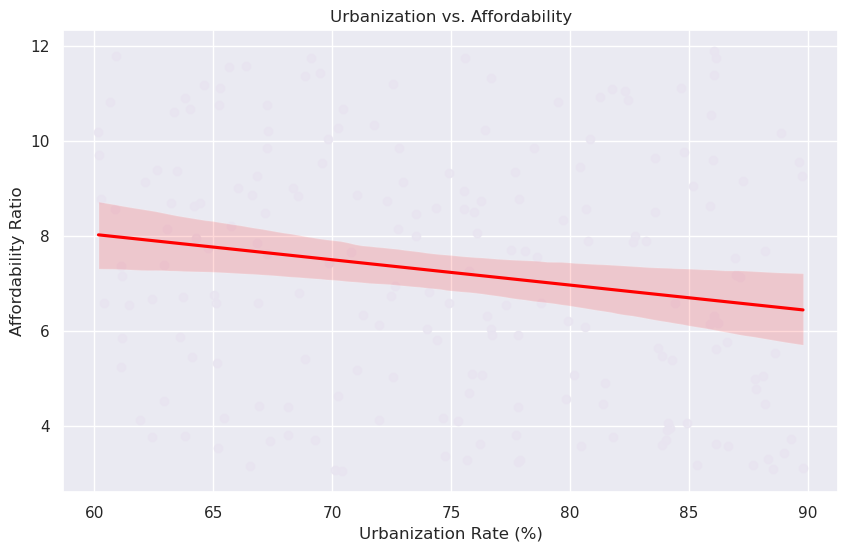

In [32]:
# ADDITIONAL ANALYSIS 

# Extra 1: Does Urbanization make housing less affordable?
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Urbanization', y='Affordability', line_kws={'color':'red'})
plt.title('Urbanization vs. Affordability')
plt.xlabel('Urbanization Rate (%)')
plt.ylabel('Affordability Ratio')
plt.show()

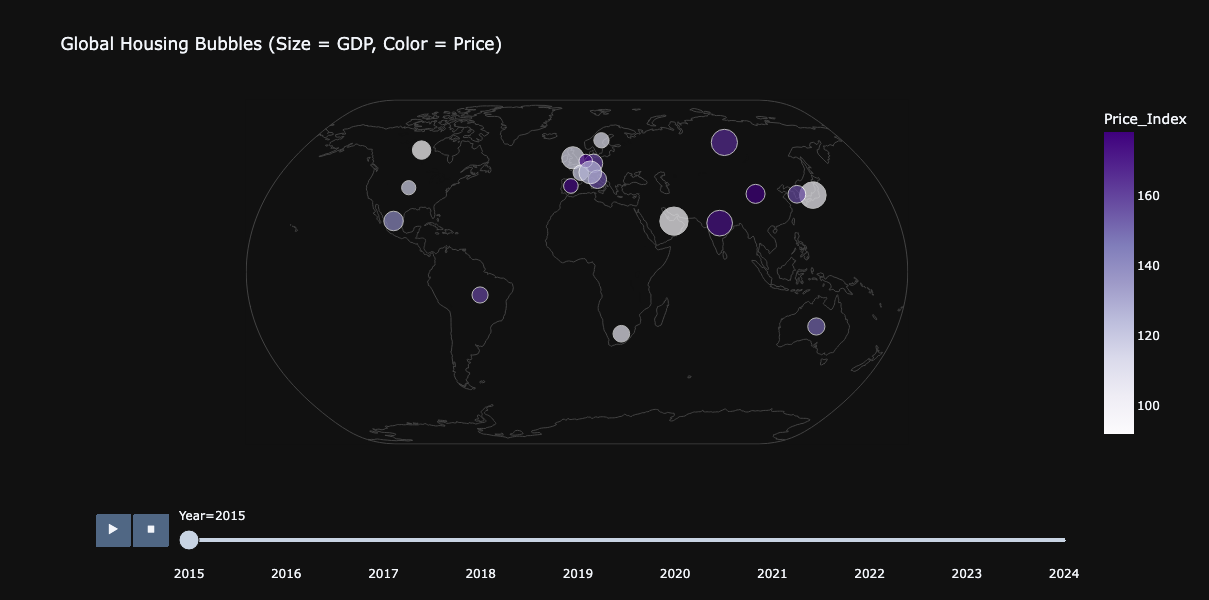

In [35]:
#NEW MAP
df['GDP_Size'] = df['GDP_Growth'].abs() + 1

# 1. NEW INTERACTIVE MAP: Bubble Map
# Unlike the first map, this uses Bubbles instead of filling the country.
# Size = GDP Strength, Color = House Price
fig_bubble = px.scatter_geo(df, 
                            locations="Country", 
                            locationmode='country names',
                            hover_name="Country", 
                            size="GDP_Size", 
                            color="Price_Index", 
                            animation_frame="Year", 
                            projection="natural earth", # Curved earth view
                            color_continuous_scale="Purples",
                            title="Global Housing Bubbles (Size = GDP, Color = Price)",
                            template="plotly_dark")
fig_bubble.update_layout(height=600, width=1000)
fig_bubble.show()

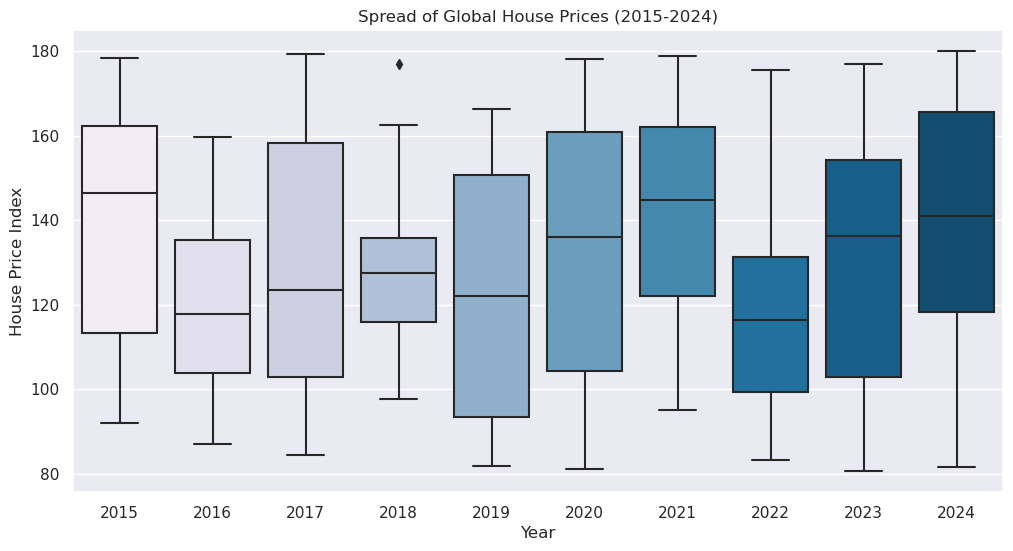

In [37]:
# 2. Box Plot Analysis
# This chart shows the "Range" of prices for each year.
# The box represents the middle 50% of countries. The lines show the outliers.
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Year', y='Price_Index', palette='PuBu')
plt.title('Spread of Global House Prices (2015-2024)')
plt.xlabel('Year')
plt.ylabel('House Price Index')
plt.show()